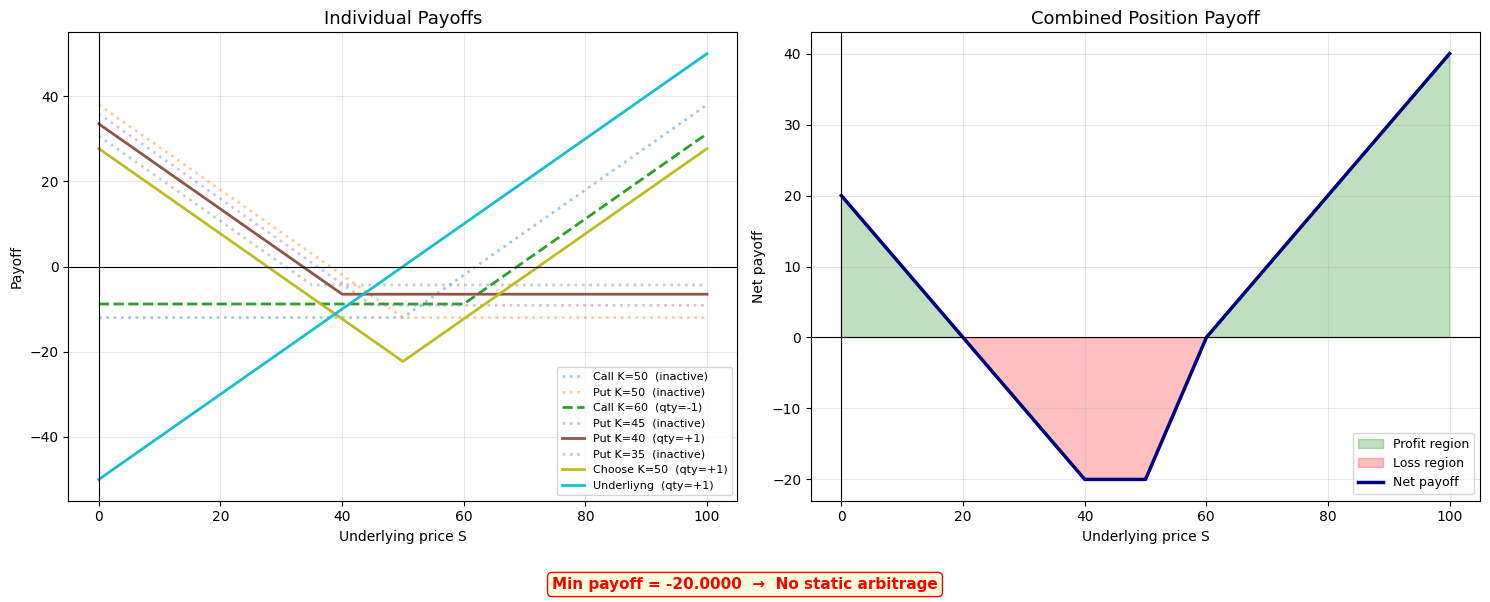

Active positions:
  SELL 1x  Call K=60
  BUY  1x  Put K=40
  BUY  1x  Choose K=50
  BUY  1x  Underliyng


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# These let you write max()/min() naturally in payoff lambdas instead of np.maximum/np.minimum
max = np.maximum
min = np.minimum

# ─────────────────────────────────────────────
# CONFIGURATION — edit this section
# ─────────────────────────────────────────────

# Underlying price range to plot
S_MIN, S_MAX = 0, 100

# Define options as a list of dicts:
#   name     : label shown in legend
#   payoff   : function of S (underlying price at expiry)
#   quantity : positive = long (buy), negative = short (sell)
#              fractional quantities are fine (e.g. 0.5)

OPTIONS = [
    {
        "name": "Call K=50",
        "payoff": lambda S: max(S - 50, 0)-12,
        "quantity": 0,
    },
    {
        "name": "Put K=50",
        "payoff": lambda S: max(50 - S, 0)-12,
        "quantity": 0,
    },
    {
        "name": "Call K=60",
        "payoff": lambda S: max(S - 60, 0)-8.8,
        "quantity": -1,
    },
    {
        "name": "Put K=45",
        "payoff": lambda S: max(45 - S, 0)-9.1,
        "quantity": 0,
    },
    {
        "name": "Put K=40",
        "payoff": lambda S: max(40 - S, 0)-6.5,
        "quantity": 1,
    },
    {
        "name": "Put K=35",
        "payoff": lambda S: max(35 - S, 0)-4.34,
        "quantity": 0,
    },
    {
        "name": "Choose K=50",
        "payoff": lambda S: max(S-50, 50-S)-22.3,
        "quantity": 1,
    },
    # {
    #     "name": "Binary Put K=40",
    #     "payoff": lambda S: np.where(S < 40, 10, 0) - 5,
    #     "quantity": 1,
    # },
    # {
    #     "name": "Knockout Put K=45, Barrier=35",
    #     "payoff": lambda S: np.where(35< S < 40, 45-S, 0) - 0.175,
    #     "quantity": 1,
    # },
    {
        "name": "Underliyng",
        "payoff": lambda S: S-50,
        "quantity": 1,
    },

]

# ─────────────────────────────────────────────
# PLOT — run cell to update
# ─────────────────────────────────────────────

S = np.linspace(S_MIN, S_MAX, 2000)

active = [o for o in OPTIONS if o["quantity"] != 0]
combined = np.zeros_like(S)

fig, (ax_ind, ax_comb) = plt.subplots(1, 2, figsize=(15, 6))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(OPTIONS), 1)))

# Left panel: individual payoffs (all options, regardless of quantity)
ax_ind.set_title("Individual Payoffs", fontsize=13)
for i, opt in enumerate(OPTIONS):
    y = opt["payoff"](S)
    q = opt["quantity"]
    style = "-" if q > 0 else ("--" if q < 0 else ":")
    alpha = 1.0 if q != 0 else 0.4
    label = f"{opt['name']}  (qty={q:+g})" if q != 0 else f"{opt['name']}  (inactive)"
    ax_ind.plot(S, y, linestyle=style, color=colors[i], alpha=alpha, lw=2, label=label)

ax_ind.axhline(0, color="black", lw=0.8)
ax_ind.axvline(0, color="black", lw=0.8)
ax_ind.set_xlabel("Underlying price S")
ax_ind.set_ylabel("Payoff")
ax_ind.legend(fontsize=8)
ax_ind.grid(True, alpha=0.3)

# Right panel: combined position payoff
ax_comb.set_title("Combined Position Payoff", fontsize=13)
for opt in active:
    combined += opt["quantity"] * opt["payoff"](S)

pos_mask = combined >= 0
ax_comb.fill_between(S, combined, 0, where=pos_mask,  alpha=0.25, color="green", label="Profit region")
ax_comb.fill_between(S, combined, 0, where=~pos_mask, alpha=0.25, color="red",   label="Loss region")
ax_comb.plot(S, combined, color="navy", lw=2.5, label="Net payoff")
ax_comb.axhline(0, color="black", lw=0.8)
ax_comb.axvline(0, color="black", lw=0.8)
ax_comb.set_xlabel("Underlying price S")
ax_comb.set_ylabel("Net payoff")
ax_comb.legend(fontsize=9)
ax_comb.grid(True, alpha=0.3)

# Arbitrage check: is combined payoff non-negative everywhere?
min_payoff = combined.min()
arb_text = (
    f"Min payoff = {min_payoff:.4f}  →  POTENTIAL ARBITRAGE (never negative!)"
    if min_payoff >= -1e-9
    else f"Min payoff = {min_payoff:.4f}  →  No static arbitrage"
)
arb_color = "green" if min_payoff >= -1e-9 else "red"
fig.text(0.5, 0.01, arb_text, ha="center", fontsize=11,
         color=arb_color, fontweight="bold",
         bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor=arb_color))

if not active:
    ax_comb.text(0.5, 0.5, "No active options\n(set quantity ≠ 0)",
                 ha="center", va="center", transform=ax_comb.transAxes, fontsize=12)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

print("Active positions:")
for opt in active:
    print(f"  {'BUY ' if opt['quantity'] > 0 else 'SELL'} {abs(opt['quantity']):g}x  {opt['name']}")
if not active:
    print("  (none — set quantity != 0 above)")


In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY

def weeks_to_years(weeks: float) -> float:
    return (weeks * 5) / TRADING_DAYS_PER_YEAR

def steps_for_weeks(weeks: float) -> int:
    return int(round(weeks * 5 * STEPS_PER_DAY))

np.random.seed(42)

# ─────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────

S = 50.0   # current underlying price
r = 0.0    # risk-free rate

# ─────────────────────────────────────────────
# PRICING FUNCTIONS
# ─────────────────────────────────────────────

def bs_price(S, K, T, r, sigma, kind):
    """Vanilla call, put, or straddle."""
    if sigma <= 0 or T <= 0:
        if kind == "call":     return max(S - K, 0)
        if kind == "put":      return max(K - S, 0)
        if kind == "straddle": return abs(S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put  = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    if kind == "call":     return call
    if kind == "put":      return put
    if kind == "straddle": return call + put

def bs_binary_put(S, K, T, r, sigma, payout=1.0):
    """Cash-or-nothing put: pays `payout` if S_T < K, else 0."""
    if sigma <= 0 or T <= 0:
        return payout if S < K else 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return payout * np.exp(-r * T) * norm.cdf(-d2)

def mc_knockout_put(S, K, T, r, sigma, barrier, weeks, n_paths=80_000):
    """Down-and-out put: pays max(K-S_T,0) if price never touches barrier, else 0.
    Uses the same discrete step count as the given model."""
    n_steps = steps_for_weeks(weeks)
    if n_steps == 0 or sigma <= 0:
        return max(K - S, 0) if S > barrier else 0.0
    dt = T / n_steps
    Z  = np.random.randn(n_paths, n_steps)
    log_paths = np.log(S) + np.cumsum((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z, axis=1)
    S_paths   = np.exp(log_paths)
    knocked   = np.any(S_paths <= barrier, axis=1)
    S_T       = S_paths[:, -1]
    payoffs   = np.where(knocked, 0.0, np.maximum(K - S_T, 0))
    return np.exp(-r * T) * np.mean(payoffs)

def price_contract(S, r, sigma, c):
    T = weeks_to_years(c["weeks"])
    if   c["type"] == "binary_put":   return bs_binary_put(S, c["K"], T, r, sigma, c.get("payout", 1.0))
    elif c["type"] == "knockout_put":  return mc_knockout_put(S, c["K"], T, r, sigma, c["barrier"], c["weeks"])
    else:                              return bs_price(S, c["K"], T, r, sigma, c["type"])

def implied_vol(S, r, c):
    mkt = c["mkt"]
    try:
        f = lambda v: price_contract(S, r, v, c) - mkt
        if f(1e-4) * f(10.0) > 0:
            return float("nan")
        return brentq(f, 1e-4, 10.0, xtol=1e-6)
    except Exception:
        return float("nan")

# ─────────────────────────────────────────────
# STEP 1: back out sigma from market prices
# ─────────────────────────────────────────────

CALIBRATION = [
    {"type": "put",          "K": 50, "weeks": 2, "mkt": 12.0},
    {"type": "put",          "K": 45, "weeks": 2, "mkt": 9.1},
    {"type": "put",          "K": 40, "weeks": 2, "mkt": 6.5},
    {"type": "put",          "K": 35, "weeks": 2, "mkt": 4.34},
    # Binary put: pays `payout` if S_T < K.  Set payout and mkt price below.
    {"type": "binary_put",   "K": 40, "weeks": 2, "mkt": 5.0,  "payout": 10.0},
    # Knockout put: down-and-out, barrier is the knock-out level.
    {"type": "knockout_put", "K": 45, "weeks": 2, "mkt": 0.175, "barrier": 35},
]

print("─── Implied vols from market prices ───")
print(f"{'Type':>14} {'K':>5} {'Barrier':>8} {'Payout':>7} {'Wks':>4} {'Mkt':>7}  {'Impl Vol':>9}")
ivs = []
for c in CALIBRATION:
    iv   = implied_vol(S, r, c)
    ivs.append(iv)
    iv_s    = f"{iv*100:.2f}%" if not np.isnan(iv) else "    n/a"
    barrier = f"{c['barrier']:.0f}" if "barrier" in c else "  —"
    payout  = f"{c.get('payout',1.0):.1f}"
    print(f"{c['type']:>14} {c['K']:>5} {barrier:>8} {payout:>7} {c['weeks']:>4} {c['mkt']:>7.4f}  {iv_s:>9}")

valid_ivs    = [v for v in ivs if not np.isnan(v)]
sigma_median = float(np.median(valid_ivs))
sigma_mean   = float(np.mean(valid_ivs))
print(f"\nMedian IV = {sigma_median*100:.2f}%   Mean IV = {sigma_mean*100:.2f}%")
print(f"Using sigma = {sigma_median*100:.2f}% (median) for pricing below\n")

sigma = sigma_median   # ← override here if you want a fixed value

# ─────────────────────────────────────────────
# STEP 2: price all contracts at consensus vol
# ─────────────────────────────────────────────

CONTRACTS = [
    {"type": "call",         "K": 50, "weeks": 2, "mkt": 12.0},
    {"type": "call",         "K": 50, "weeks": 3, "mkt": 12.0},
    {"type": "call",         "K": 60, "weeks": 2, "mkt": 8.8},
    {"type": "put",          "K": 50, "weeks": 2, "mkt": 12.0},
    {"type": "put",          "K": 45, "weeks": 2, "mkt": 9.1},
    {"type": "put",          "K": 40, "weeks": 2, "mkt": 6.5},
    {"type": "put",          "K": 35, "weeks": 2, "mkt": 4.34},
    {"type": "straddle",     "K": 50, "weeks": 2, "mkt": 22.3},
    {"type": "binary_put",   "K": 40, "weeks": 2, "mkt": 5.0,  "payout": 10.0},
    {"type": "knockout_put", "K": 45, "weeks": 2, "mkt": 0.175, "barrier": 35},
]

print(f"─── Pricing at sigma = {sigma*100:.2f}%  (S={S}, r={r}) ───")
header = f"{'Type':>14} {'K':>5} {'Info':>8} {'Wks':>4} | {'BS Theo':>8} {'Mkt':>8} {'Edge':>8} {'IV':>8}  Signal"
print(header)
print("─" * len(header))

for c in CONTRACTS:
    theo = price_contract(S, r, sigma, c)
    mkt  = c["mkt"]
    edge = theo - mkt
    iv   = implied_vol(S, r, c)
    iv_s = f"{iv*100:.1f}%" if not np.isnan(iv) else "   n/a"

    info = f"B={c['barrier']}" if "barrier" in c else (f"pay={c.get('payout',1)}" if c["type"]=="binary_put" else "  —")

    if   edge >  0.05: signal = "BUY  ← undervalued"
    elif edge < -0.05: signal = "SELL ← overvalued"
    else:              signal = "fair"

    print(f"{c['type']:>14} {c['K']:>5} {info:>8} {c['weeks']:>4} | {theo:>8.3f} {mkt:>8.3f} {edge:>+8.3f} {iv_s:>8}  {signal}")

print("\nEdge = Theo − Market.  Positive → cheap → BUY.  Negative → expensive → SELL.")
print("IVs that deviate from the consensus are mispriced relative to the vol surface.")


── 2-week (40 steps) ──
  Theoretical E[S_T]    = 50.00  (zero drift → E[S_T] = S0)
  Simulated  mean S_T   = 50.0679
  Simulated  median S_T = 43.8601
  Simulated  std  S_T   = 26.6220
  Simulated  P(S_T < 35) = 31.86%
  Simulated  P(S_T < 40) = 42.03%
  Simulated  P(S_T < 45) = 51.92%
  Simulated  P(S_T > 60) = 27.12%

── 3-week (60 steps) ──
  Theoretical E[S_T]    = 50.00  (zero drift → E[S_T] = S0)
  Simulated  mean S_T   = 50.2948
  Simulated  median S_T = 42.0640
  Simulated  std  S_T   = 33.7064
  Simulated  P(S_T < 35) = 38.42%
  Simulated  P(S_T < 40) = 46.78%
  Simulated  P(S_T < 45) = 54.34%
  Simulated  P(S_T > 60) = 28.01%



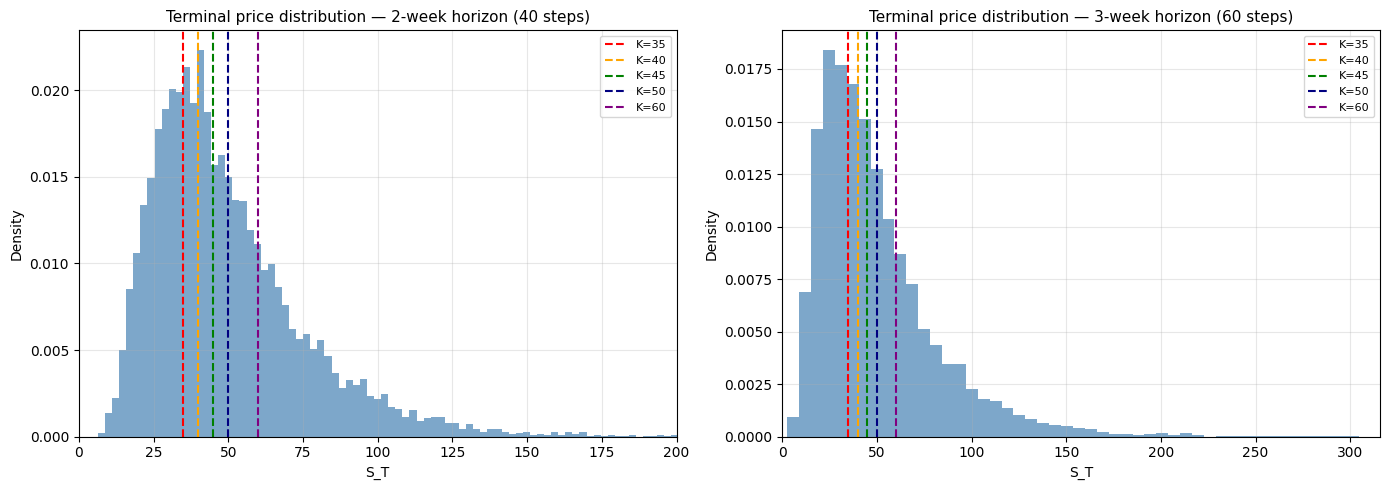

Stored for later use:
  mc_paths_2w    shape (10000, 40)   (full paths, 2-week)
  mc_paths_3w    shape (10000, 60)   (full paths, 3-week)
  mc_terminal_2w shape (10000,)  (terminal prices, 2-week)
  mc_terminal_3w shape (10000,)  (terminal prices, 3-week)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ── Model parameters (from problem statement) ──────────────────────────────
SIGMA        = 2.51          # 251% annualized vol
DRIFT        = 0.0           # zero risk-neutral drift
STEPS_PER_DAY        = 4
TRADING_DAYS_PER_YEAR = 252
STEPS_PER_YEAR        = STEPS_PER_DAY * TRADING_DAYS_PER_YEAR   # 1008
DT           = 1.0 / STEPS_PER_YEAR                              # one step in years

S0           = 50.0          # current price — update if needed
N_PATHS      = 10_000
N_STEPS_2W   = 4 * 10       # 40 steps  (2 weeks = 10 trading days)
N_STEPS_3W   = 4 * 15       # 60 steps  (3 weeks = 15 trading days)

# ── Simulate ────────────────────────────────────────────────────────────────
rng = np.random.default_rng(seed=0)   # fixed seed → reproducible

def simulate_paths(S0, n_steps, n_paths):
    """Returns array of shape (n_paths, n_steps) — full price paths."""
    Z         = rng.standard_normal((n_paths, n_steps))
    log_steps = (DRIFT - 0.5 * SIGMA**2) * DT + SIGMA * np.sqrt(DT) * Z
    log_paths = np.log(S0) + np.cumsum(log_steps, axis=1)
    return np.exp(log_paths)           # shape: (n_paths, n_steps)

mc_paths_2w = simulate_paths(S0, N_STEPS_2W, N_PATHS)   # (10000, 40)
mc_paths_3w = simulate_paths(S0, N_STEPS_3W, N_PATHS)   # (10000, 60)

mc_terminal_2w = mc_paths_2w[:, -1]   # final price each trial, 2-week horizon
mc_terminal_3w = mc_paths_3w[:, -1]   # final price each trial, 3-week horizon

# ── Summary stats ────────────────────────────────────────────────────────────
for label, term, n_steps in [("2-week (40 steps)", mc_terminal_2w, N_STEPS_2W),
                              ("3-week (60 steps)", mc_terminal_3w, N_STEPS_3W)]:
    T = n_steps * DT
    print(f"── {label} ──")
    print(f"  Theoretical E[S_T]    = {S0:.2f}  (zero drift → E[S_T] = S0)")
    print(f"  Simulated  mean S_T   = {term.mean():.4f}")
    print(f"  Simulated  median S_T = {np.median(term):.4f}")
    print(f"  Simulated  std  S_T   = {term.std():.4f}")
    print(f"  Simulated  P(S_T < 35) = {(term < 35).mean()*100:.2f}%")
    print(f"  Simulated  P(S_T < 40) = {(term < 40).mean()*100:.2f}%")
    print(f"  Simulated  P(S_T < 45) = {(term < 45).mean()*100:.2f}%")
    print(f"  Simulated  P(S_T > 60) = {(term > 60).mean()*100:.2f}%")
    print()

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, term, label, paths in [
    (axes[0], mc_terminal_2w, "2-week horizon (40 steps)", mc_paths_2w),
    (axes[1], mc_terminal_3w, "3-week horizon (60 steps)", mc_paths_3w),
]:
    ax.hist(term, bins=100, color="steelblue", alpha=0.7, edgecolor="none", density=True)
    for strike, col in [(35, "red"), (40, "orange"), (45, "green"), (50, "navy"), (60, "purple")]:
        ax.axvline(strike, color=col, lw=1.5, linestyle="--", label=f"K={strike}")
    ax.set_title(f"Terminal price distribution — {label}", fontsize=11)
    ax.set_xlabel("S_T")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_xlim(0, max(term.max() * 0.5, 200))   # clip extreme right tail for readability
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Stored for later use:")
print(f"  mc_paths_2w    shape {mc_paths_2w.shape}   (full paths, 2-week)")
print(f"  mc_paths_3w    shape {mc_paths_3w.shape}   (full paths, 3-week)")
print(f"  mc_terminal_2w shape {mc_terminal_2w.shape}  (terminal prices, 2-week)")
print(f"  mc_terminal_3w shape {mc_terminal_3w.shape}  (terminal prices, 3-week)")


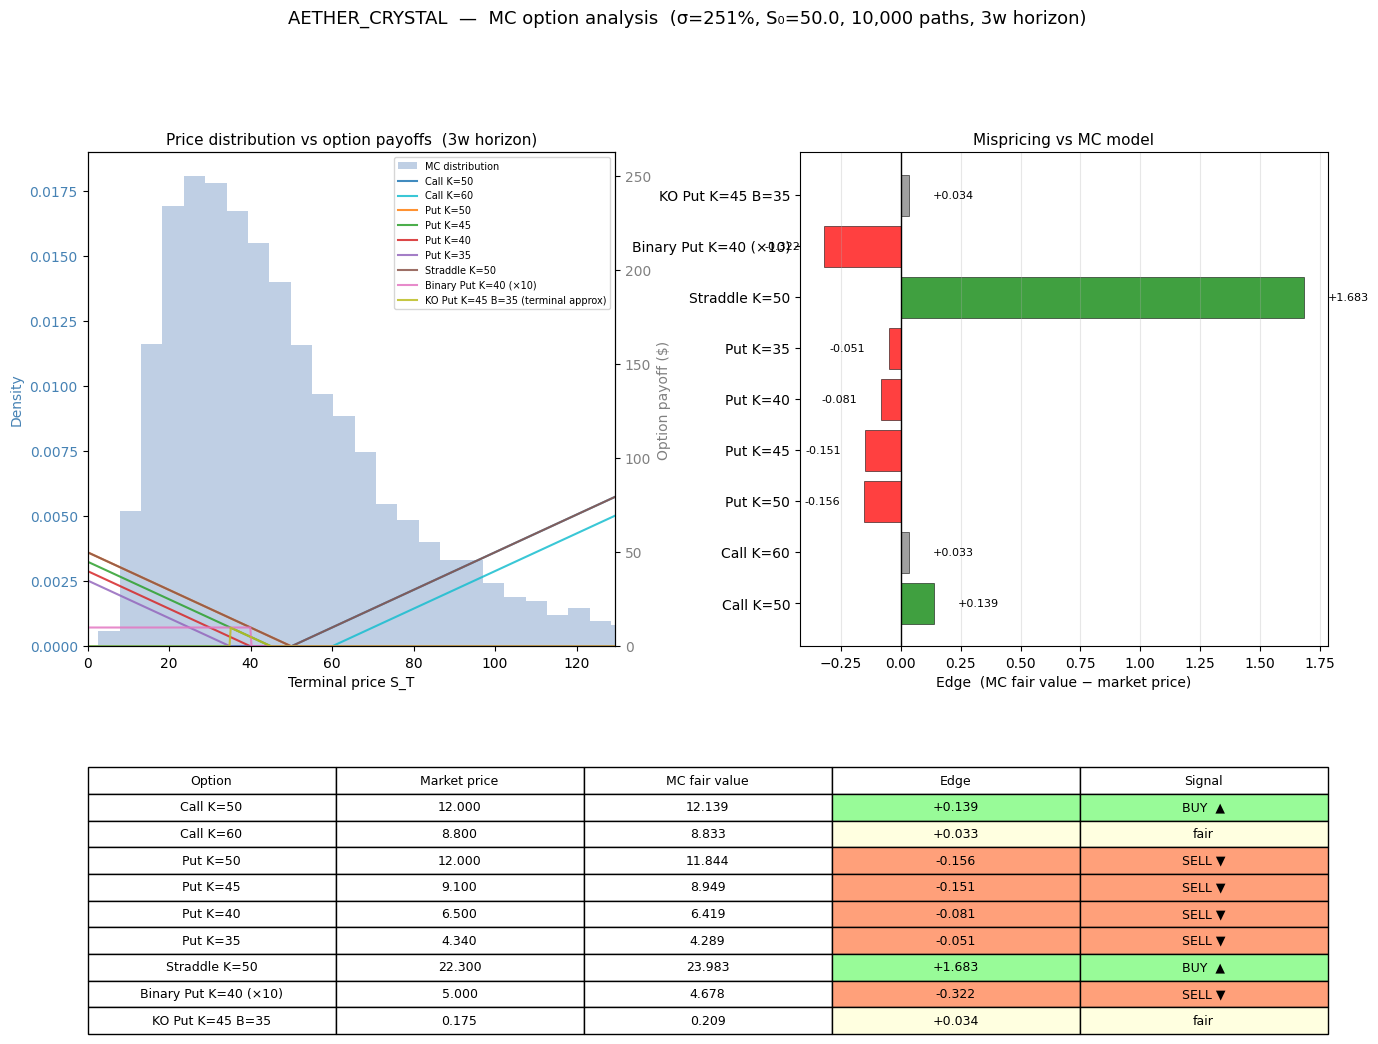

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Options to compare (no premium offset — just intrinsic payoff) ──────────
max = np.maximum
min = np.minimum

HORIZON = "3w"     # "2w" or "3w"
term    = mc_terminal_2w if HORIZON == "2w" else mc_terminal_3w
paths   = mc_paths_2w    if HORIZON == "2w" else mc_paths_3w

# ── Update mkt prices to the correct 3-week premiums ───────────────────────
CONTRACTS = [
    {"name": "Underlying Asset 10x", "payoff": lambda S: S,                            "mkt": 50.00, "color": "tab:blue"},
    {"name": "Call K=50",            "payoff": lambda S: max(S-50, 0),                 "mkt": 12.00, "color": "tab:blue"},
    {"name": "Call K=60",            "payoff": lambda S: max(S-60, 0),                 "mkt": 8.80,  "color": "tab:cyan"},
    {"name": "Put K=50",             "payoff": lambda S: max(50-S, 0),                 "mkt": 12.00, "color": "tab:orange"},
    {"name": "Put K=45",             "payoff": lambda S: max(45-S, 0),                 "mkt": 9.10,  "color": "tab:green"},
    {"name": "Put K=40",             "payoff": lambda S: max(40-S, 0),                 "mkt": 6.50,  "color": "tab:red"},
    {"name": "Put K=35",             "payoff": lambda S: max(35-S, 0),                 "mkt": 4.34,  "color": "tab:purple"},
    {"name": "Straddle K=50",        "payoff": lambda S: max(S-50,0)+max(50-S,0),      "mkt": 22.30, "color": "tab:brown"},
    {"name": "Binary Put K=40 (×10)","payoff": lambda S: np.where(S < 40, 10.0, 0.0), "mkt": 5.00,  "color": "tab:pink"},
    {"name": "KO Put K=45 B=35",     "payoff": None,                                   "mkt": 0.175, "color": "tab:olive"},
]
# ^^^ Fill in the correct 3-week market prices above (currently 2-week prices as placeholders)

# ── Compute MC fair values ───────────────────────────────────────────────────
for c in CONTRACTS:
    if c["name"].startswith("KO"):
        knocked = np.any(paths <= 35, axis=1)          # uses 3w paths when HORIZON="3w"
        c["mc_price"] = np.mean(np.where(knocked, 0.0, np.maximum(45 - term, 0)))
    else:
        c["mc_price"] = np.mean(c["payoff"](term))     # uses 3w terminal prices
    c["edge"] = c["mc_price"] - c["mkt"]

# ── Figure layout ────────────────────────────────────────────────────────────
S_grid = np.linspace(0, 300, 1000)

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, height_ratios=[2.5, 1], hspace=0.45, wspace=0.35)
ax_dist  = fig.add_subplot(gs[0, 0])
ax_edge  = fig.add_subplot(gs[0, 1])
ax_table = fig.add_subplot(gs[1, :])

# ── Top-left: distribution + payoff curves ───────────────────────────────────
ax2 = ax_dist.twinx()

ax_dist.hist(term, bins=120, density=True, color="lightsteelblue",
             edgecolor="none", alpha=0.8, label="MC distribution")
ax_dist.set_xlabel("Terminal price S_T")
ax_dist.set_ylabel("Density", color="steelblue")
ax_dist.set_xlim(0, np.percentile(term, 97))
ax_dist.tick_params(axis="y", labelcolor="steelblue")
ax_dist.set_title(f"Price distribution vs option payoffs  ({HORIZON} horizon)", fontsize=11)

for c in CONTRACTS:
    if c["name"].startswith("KO"):
        y = np.where(S_grid > 35, np.maximum(45 - S_grid, 0), 0.0)
        label = c["name"] + " (terminal approx)"
    else:
        y = c["payoff"](S_grid)
        label = c["name"]
    ax2.plot(S_grid, y, color=c["color"], lw=1.5, label=label, alpha=0.85)

ax2.set_ylabel("Option payoff ($)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax2.set_ylim(bottom=0)

lines1, labels1 = ax_dist.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_dist.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

# ── Top-right: edge bar chart ────────────────────────────────────────────────
names  = [c["name"] for c in CONTRACTS]
edges  = [c["edge"]  for c in CONTRACTS]
colors_bar = ["green" if e > 0.05 else ("red" if e < -0.05 else "gray") for e in edges]

bars = ax_edge.barh(names, edges, color=colors_bar, alpha=0.75, edgecolor="black", linewidth=0.5)
ax_edge.axvline(0, color="black", lw=1.0)
ax_edge.set_xlabel("Edge  (MC fair value − market price)")
ax_edge.set_title("Mispricing vs MC model", fontsize=11)
ax_edge.grid(True, axis="x", alpha=0.3)
for bar, e in zip(bars, edges):
    ax_edge.text(e + (0.1 if e >= 0 else -0.1), bar.get_y() + bar.get_height()/2,
                 f"{e:+.3f}", va="center", ha="left" if e >= 0 else "right", fontsize=8)

# ── Bottom: summary table ────────────────────────────────────────────────────
ax_table.axis("off")
col_labels = ["Option", "Market price", "MC fair value", "Edge", "Signal"]
rows = []
for c in CONTRACTS:
    sig = "BUY  ▲" if c["edge"] > 0.05 else ("SELL ▼" if c["edge"] < -0.05 else "fair")
    rows.append([c["name"], f"{c['mkt']:.3f}", f"{c['mc_price']:.3f}", f"{c['edge']:+.3f}", sig])

tbl = ax_table.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for i, c in enumerate(CONTRACTS):
    clr = "palegreen" if c["edge"] > 0.05 else ("lightsalmon" if c["edge"] < -0.05 else "lightyellow")
    tbl[(i+1, 3)].set_facecolor(clr)
    tbl[(i+1, 4)].set_facecolor(clr)

plt.suptitle(f"AETHER_CRYSTAL  —  MC option analysis  (σ=251%, S₀={S0}, {N_PATHS:,} paths, {HORIZON} horizon)",
             fontsize=13, y=1.01)
plt.savefig("option_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ── Settings ─────────────────────────────────────────────────────────────────
ALPHA    = 0.95
MAX_QTY  = 3
N_LAMBDA = 120    # denser frontier
N_RESTARTS = 5

# ── Target point to inspect ───────────────────────────────────────────────────
TARGET_CVAR = 70   # ← change these to explore different frontier points
TARGET_EP   = 19

max = np.maximum
min = np.minimum

N_STEPS_2W = 4 * 10
term_3w = mc_paths_3w[:, -1]
term_2w = mc_paths_3w[:, N_STEPS_2W - 1]

OPT_CONTRACTS = [
    {"name": "Underlying ×4",        "mkt": 200.00, "payoff": lambda S: 4*S,                        "term": term_3w},
    {"name": "Call K=50 (2w)",       "mkt": 12.00,  "payoff": lambda S: max(S-50, 0),               "term": term_2w},
    {"name": "Call K=50 (3w)",       "mkt": 12.00,  "payoff": lambda S: max(S-50, 0),               "term": term_3w},
    {"name": "Call K=60",            "mkt": 8.80,   "payoff": lambda S: max(S-60, 0),               "term": term_3w},
    {"name": "Put K=50 (2w)",        "mkt": 12.00,  "payoff": lambda S: max(50-S, 0),               "term": term_2w},
    {"name": "Put K=50 (3w)",        "mkt": 12.00,  "payoff": lambda S: max(50-S, 0),               "term": term_3w},
    {"name": "Put K=45",             "mkt": 9.10,   "payoff": lambda S: max(45-S, 0),               "term": term_3w},
    {"name": "Put K=40",             "mkt": 6.50,   "payoff": lambda S: max(40-S, 0),               "term": term_3w},
    {"name": "Put K=35",             "mkt": 4.34,   "payoff": lambda S: max(35-S, 0),               "term": term_3w},
    {"name": "Straddle K=50",        "mkt": 22.30,  "payoff": lambda S: max(S-50,0)+max(50-S,0),   "term": term_3w},
    {"name": "Binary Put K=40 (×10)","mkt": 5.00,   "payoff": lambda S: np.where(S<40, 10.0, 0.0), "term": term_3w},
    {"name": "KO Put K=45 B=35 10x", "mkt": 1.75,  "payoff": None,                                 "term": term_3w, "mult": 10},
]

N, M = len(term_3w), len(OPT_CONTRACTS)
payoff_mat = np.zeros((N, M))
for j, c in enumerate(OPT_CONTRACTS):
    if c["payoff"] is None:
        knocked = np.any(mc_paths_3w <= 35, axis=1)
        payoff_mat[:, j] = np.where(knocked, 0.0, c.get("mult", 1) * np.maximum(45 - c["term"], 0))
    else:
        payoff_mat[:, j] = c["payoff"](c["term"])

mkt_vec  = np.array([c["mkt"] for c in OPT_CONTRACTS])
edge_mat = payoff_mat - mkt_vec

def pnl(q):          return edge_mat @ q
def expected_pnl(q): return np.mean(pnl(q))
def cvar(q):
    p = pnl(q)
    return -np.mean(p[p <= np.percentile(p, (1-ALPHA)*100)])
def objective(q, lam): return -(expected_pnl(q) - lam * cvar(q))

bounds = [(-MAX_QTY, MAX_QTY)] * M

# ── Trace efficient frontier ──────────────────────────────────────────────────
rng_opt = np.random.default_rng(7)
lambdas = np.logspace(-2, 2, N_LAMBDA)
raw_results = []
for lam in lambdas:
    best = None
    for _ in range(N_RESTARTS):
        q0  = rng_opt.uniform(-0.5, 0.5, M)
        res = minimize(objective, q0, args=(lam,), method="SLSQP",
                       bounds=bounds, options={"maxiter": 800, "ftol": 1e-9})
        q_opt = np.clip(res.x, -MAX_QTY, MAX_QTY)
        ep, cv = expected_pnl(q_opt), cvar(q_opt)
        if best is None or ep - lam*cv > best[0] - lam*best[1]:
            best = (ep, cv, q_opt, lam)
    if best:
        raw_results.append(best)

raw_results.sort(key=lambda r: r[1])
frontier, max_ep = [], -np.inf
for r in raw_results:
    if r[0] > max_ep:
        frontier.append(r); max_ep = r[0]

f_ep = np.array([r[0] for r in frontier])
f_cv = np.array([r[1] for r in frontier])
f_q  = np.array([r[2] for r in frontier])

# Fixed portfolio indices
idx_c, idx_b, idx_a = 0, len(frontier)//2, len(frontier)-1
portfolios = [("Conservative", idx_c, "green"), ("Balanced", idx_b, "gold"), ("Aggressive", idx_a, "red")]

# Find the frontier point closest to the target
dist   = np.sqrt(((f_cv - TARGET_CVAR) / (f_cv.max() - f_cv.min()))**2 +
                 ((f_ep - TARGET_EP)   / (f_ep.max() - f_ep.min()))**2)
idx_t  = int(np.argmin(dist))

# ── Figure 1: efficient frontier ─────────────────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

ax1.plot(f_cv, f_ep, "b-o", markersize=4, lw=2, label="Efficient frontier", zorder=3)
ax1.axhline(0, color="black", lw=0.8, ls="--")
for j, c in enumerate(OPT_CONTRACTS):
    q_s = np.zeros(M); q_s[j] = 1.0
    ax1.scatter(cvar(q_s), expected_pnl(q_s), s=60, zorder=5, label=c["name"])
for label, idx, col in portfolios:
    ax1.scatter(f_cv[idx], f_ep[idx], s=180, marker="*", color=col, zorder=10, label=label)

# Highlight target point
ax1.scatter(f_cv[idx_t], f_ep[idx_t], s=300, marker="D", color="crimson", zorder=11, label=f"Target ≈({TARGET_CVAR},{TARGET_EP})")
ax1.annotate(f"  Target\n  CVaR={f_cv[idx_t]:.1f}\n  E[PnL]={f_ep[idx_t]:.1f}",
             xy=(f_cv[idx_t], f_ep[idx_t]), fontsize=8, color="crimson",
             xytext=(f_cv[idx_t]+2, f_ep[idx_t]-1))

ax1.set_xlabel(f"CVaR {int(ALPHA*100)}%")
ax1.set_ylabel("Expected P&L")
ax1.set_title(f"Efficient frontier  ({len(frontier)} points)")
ax1.legend(fontsize=7, loc="lower right")
ax1.grid(True, alpha=0.3)

# Target portfolio composition
tgt_q   = f_q[idx_t]
names   = [c["name"] for c in OPT_CONTRACTS]
bar_col = ["steelblue" if v > 0 else "tomato" for v in tgt_q]
bars = ax2.barh(names, tgt_q, color=bar_col, alpha=0.8, edgecolor="black", lw=0.5)
ax2.axvline(0, color="black", lw=1.0)
for bar, v in zip(bars, tgt_q):
    if abs(v) > 0.05:
        ax2.text(v + (0.05 if v >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax2.set_xlabel("Position size  (+ = long,  − = short)")
ax2.set_title(f"Target portfolio  CVaR={f_cv[idx_t]:.1f}  E[PnL]={f_ep[idx_t]:.1f}")
ax2.grid(True, axis="x", alpha=0.3)
plt.suptitle("Portfolio optimisation  (3-week horizon, σ=251%)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Figure 2: payoff graphs for conservative / balanced / aggressive / TARGET ─
all_ports = portfolios + [("Target", idx_t, "crimson")]
fig2, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)

S_lo = np.percentile(term_3w, 2)
S_hi = np.percentile(term_3w, 98)
bins = np.linspace(S_lo, S_hi, 70)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

for ax, (label, idx, color) in zip(axes, all_ports):
    q     = f_q[idx]
    p_vec = pnl(q)

    means, stds = [], []
    for k in range(len(bin_centers)):
        mask = (term_3w >= bins[k]) & (term_3w < bins[k+1])
        if mask.sum() >= 5:
            means.append(np.mean(p_vec[mask]))
            stds.append(np.std(p_vec[mask]))
        else:
            means.append(np.nan); stds.append(np.nan)

    means, stds = np.array(means), np.array(stds)
    valid = ~np.isnan(means)
    x, m, s = bin_centers[valid], means[valid], stds[valid]

    ax.fill_between(x, m-s, m+s, alpha=0.18, color=color, label="±1 std")
    ax.fill_between(x, m, 0, where=(m >= 0), alpha=0.20, color="green")
    ax.fill_between(x, m, 0, where=(m <  0), alpha=0.20, color="red")
    ax.plot(x, m, color=color, lw=2.5)
    ax.axhline(0, color="black", lw=1.0, ls="--")
    ax.axvline(S0, color="gray", lw=1.0, ls=":", label=f"S₀={S0}")
    for sc in np.where(np.diff(np.sign(m)))[0]:
        ax.axvline(x[sc], color="purple", lw=1.0, ls="--", alpha=0.6)
        ax.text(x[sc]+0.5, m.min()*0.9, f"BE≈{x[sc]:.0f}", fontsize=7, color="purple")
    ax.set_xlabel("3-week terminal price S_T")
    ax.set_ylabel("Net P&L")
    ax.set_title(f"{label}\nE[PnL]={f_ep[idx]:+.2f}  CVaR={f_cv[idx]:.1f}  P(+)={np.mean(p_vec>0)*100:.0f}%")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Portfolio net P&L vs 3-week terminal price", fontsize=12)
plt.tight_layout()
plt.show()

# ── Print all key portfolios ──────────────────────────────────────────────────
for label, idx, _ in all_ports:
    q = f_q[idx]
    p = pnl(q)
    print(f"\n── {label} ──  E[PnL]={f_ep[idx]:+.3f}   CVaR={f_cv[idx]:.3f}   "
          f"P(profit)={np.mean(p>0)*100:.1f}%   worst={p.min():+.2f}")
    for j, c in enumerate(OPT_CONTRACTS):
        if abs(q[j]) > 0.05:
            print(f"   {'LONG ' if q[j]>0 else 'SHORT'} {abs(q[j]):.2f}x  {c['name']}")


In [38]:
import numpy as np

# ── Set your actual position limit ───────────────────────────────────────────
ACTUAL_MAX = 50    # ← your real max units per contract

scale = ACTUAL_MAX / MAX_QTY   # MAX_QTY=3 from the optimisation cell above

print(f"Scale factor:  {ACTUAL_MAX} / {MAX_QTY} = {scale:.4f}x\n")
print("Scaling is exact: E[PnL], CVaR, and worst-case loss all multiply by the same factor.")
print("The position ratios between contracts are unchanged.\n")

# ── Scaled summary for all portfolios ────────────────────────────────────────
header = f"{'Portfolio':>14} {'E[PnL]':>10} {'CVaR':>10} {'P(profit)':>10} {'Worst':>10}"
print(header)
print("─" * len(header))

all_ports_scaled = [("Conservative", idx_c, "green"),
                    ("Balanced",     idx_b, "gold"),
                    ("Aggressive",   idx_a, "red"),
                    ("Target",       idx_t, "crimson")]

for label, idx, _ in all_ports_scaled:
    q     = f_q[idx] * scale
    p_vec = pnl(f_q[idx]) * scale        # scale the raw P&L vector
    ep_s  = f_ep[idx] * scale
    cv_s  = f_cv[idx] * scale
    pp    = np.mean(p_vec > 0) * 100
    worst = p_vec.min()
    print(f"{label:>14} {ep_s:>+10.2f} {cv_s:>10.2f} {pp:>9.1f}% {worst:>+10.2f}")

# ── Scaled positions for each portfolio ──────────────────────────────────────
print()
for label, idx, _ in all_ports_scaled:
    q_scaled = f_q[idx] * scale
    print(f"\n── {label}  (scaled to MAX_QTY={ACTUAL_MAX}) ──")
    for j, c in enumerate(OPT_CONTRACTS):
        v = q_scaled[j]
        if abs(v) > 0.05:
            at_limit = " ← AT LIMIT" if abs(v) >= ACTUAL_MAX - 0.05 else ""
            print(f"   {'LONG ' if v>0 else 'SHORT'} {abs(v):6.2f}x  {c['name']}{at_limit}")

# ── Caveat ────────────────────────────────────────────────────────────────────
print()
print("Note: positions marked 'AT LIMIT' were also at the MAX_QTY=3 bound.")
print("Those that are NOT at the limit could go even higher at MAX_QTY=50,")
print("meaning the true optimal at MAX_QTY=50 is at least as good as these scaled numbers.")
print("Re-run the optimisation cell with MAX_QTY=50 for the exact MAX_QTY=50 frontier.")


Scale factor:  50 / 3 = 16.6667x

Scaling is exact: E[PnL], CVaR, and worst-case loss all multiply by the same factor.
The position ratios between contracts are unchanged.

     Portfolio     E[PnL]       CVaR  P(profit)      Worst
──────────────────────────────────────────────────────────
  Conservative    +105.23     -86.22      99.8%     -50.48
      Balanced    +164.31     -55.22      98.8%    -333.68
    Aggressive    +435.04    4100.23      32.1%   -7187.27
        Target    +335.29     616.33      75.0%   -4252.73


── Conservative  (scaled to MAX_QTY=50) ──
   SHORT  50.00x  Call K=50 (3w) ← AT LIMIT
   SHORT  50.00x  Put K=50 (3w) ← AT LIMIT
   LONG   15.18x  Put K=45
   SHORT  50.00x  Put K=40 ← AT LIMIT
   LONG   34.82x  Put K=35
   LONG   50.00x  Straddle K=50 ← AT LIMIT
   LONG    9.82x  Binary Put K=40 (×10)
   SHORT  15.18x  KO Put K=45 B=35 10x

── Balanced  (scaled to MAX_QTY=50) ──
   SHORT   6.21x  Underlying ×4
   SHORT   0.16x  Call K=50 (2w)
   SHORT  25.46x  Call

── Manual portfolio stats ──
  Expected P&L : +20.1139
  CVaR 95%     : 36.9718
  P(profit)    : 75.2%
  Worst path   : -259.4057
  Best path    : +377.6243

  Positions:
    SHORT 0.46x  Underlying ×4
    SHORT 1.45x  Call K=50 (2w)
    LONG  1.49x  Call K=50 (3w)
    SHORT 1.68x  Call K=60
    SHORT 3x  Put K=50 (2w)
    LONG  0.39x  Put K=50 (3w)
    SHORT 3x  Put K=45
    LONG  1.86x  Put K=40
    SHORT 2.47x  Put K=35
    LONG  3x  Straddle K=50
    SHORT 3x  Binary Put K=40 (×10)
    SHORT 3x  KO Put K=45 B=35 10x


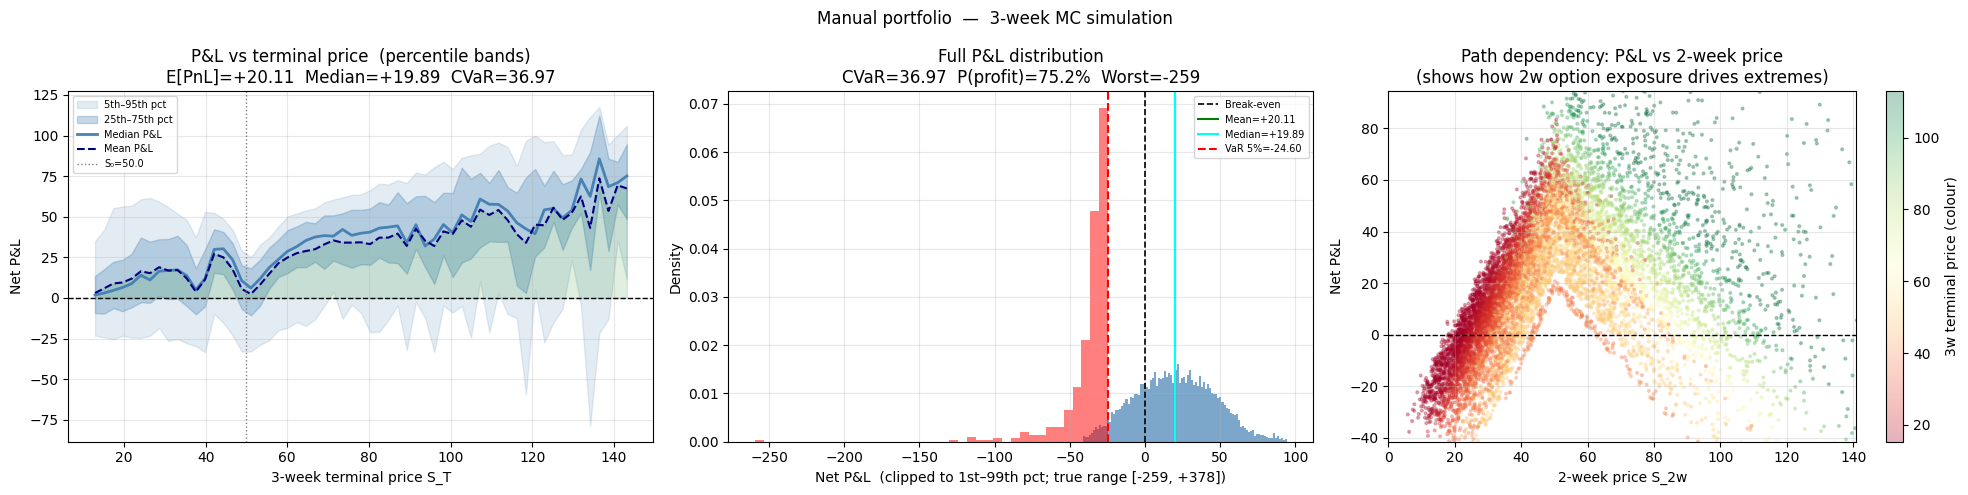


── Worst-10 paths decomposition ──
   Path      S_2w      S_3w    Total PnL   KO knocked
   1471    397.32    258.76      -259.41           no
   4895    239.24    158.98      -126.98           no
   4811    216.25    134.82      -117.09           no
   9943    178.45     79.51      -115.92           no
   8283    163.37     45.03      -113.48           no
   9581    160.61     61.11      -107.90           no
   4706    229.43    167.13      -104.85           no
   1788    222.20    163.26       -98.12           no
   8386    153.52     61.18       -97.56           no
   1512    183.30    118.39       -85.24           no


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ── YOUR POSITIONS — edit quantities here ─────────────────────────────────────
MY_POSITIONS = {
    "Underlying ×4":           -0.46,
    "Call K=50 (2w)":          -1.45,
    "Call K=50 (3w)":          +1.49,
    "Call K=60":               -1.68,
    "Put K=50 (2w)":           -3.00,
    "Put K=50 (3w)":           +0.39,
    "Put K=45":                -3.00,
    "Put K=40":                +1.86,
    "Put K=35":                -2.47,
    "Straddle K=50":           +3.00,
    "Binary Put K=40 (×10)":   -3.00,
    "KO Put K=45 B=35 10x":    -3.00,
}

q_manual = np.array([MY_POSITIONS.get(c["name"], 0) for c in OPT_CONTRACTS], dtype=float)
p_vec    = pnl(q_manual)

ep    = np.mean(p_vec)
cv    = cvar(q_manual)
pp    = np.mean(p_vec > 0) * 100
worst = p_vec.min()
best  = p_vec.max()

print("── Manual portfolio stats ──")
print(f"  Expected P&L : {ep:+.4f}")
print(f"  CVaR 95%     : {cv:.4f}")
print(f"  P(profit)    : {pp:.1f}%")
print(f"  Worst path   : {worst:+.4f}")
print(f"  Best path    : {best:+.4f}")
print()
print("  Positions:")
for j, c in enumerate(OPT_CONTRACTS):
    v = q_manual[j]
    if v != 0:
        print(f"    {'LONG ' if v > 0 else 'SHORT'} {abs(v):g}x  {c['name']}")

# ── Payoff graph ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Left: percentile bands vs 3w terminal price ───────────────────────────────
ax1 = axes[0]
S_lo = np.percentile(term_3w, 2)
S_hi = np.percentile(term_3w, 98)
bins = np.linspace(S_lo, S_hi, 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

p5, p25, p50, p75, p95, means_b = [], [], [], [], [], []
for k in range(len(bin_centers)):
    mask = (term_3w >= bins[k]) & (term_3w < bins[k+1])
    if mask.sum() >= 10:
        v = p_vec[mask]
        p5.append(np.percentile(v, 5));   p25.append(np.percentile(v, 25))
        p50.append(np.median(v));          p75.append(np.percentile(v, 75))
        p95.append(np.percentile(v, 95)); means_b.append(np.mean(v))
    else:
        for lst in [p5, p25, p50, p75, p95, means_b]: lst.append(np.nan)

p5, p25, p50, p75, p95, means_b = [np.array(a) for a in [p5, p25, p50, p75, p95, means_b]]
v = ~np.isnan(p50)
x = bin_centers[v]

ax1.fill_between(x, p5[v],  p95[v], alpha=0.15, color="steelblue", label="5th–95th pct")
ax1.fill_between(x, p25[v], p75[v], alpha=0.30, color="steelblue", label="25th–75th pct")
ax1.plot(x, p50[v],    color="steelblue", lw=2.0, label="Median P&L")
ax1.plot(x, means_b[v],color="navy",     lw=1.5, ls="--", label="Mean P&L")
ax1.fill_between(x, means_b[v], 0, where=(means_b[v] >= 0), alpha=0.12, color="green")
ax1.fill_between(x, means_b[v], 0, where=(means_b[v] <  0), alpha=0.12, color="red")
ax1.axhline(0, color="black", lw=1.0, ls="--")
ax1.axvline(S0, color="gray", lw=1.0, ls=":", label=f"S₀={S0}")
ax1.set_xlabel("3-week terminal price S_T")
ax1.set_ylabel("Net P&L")
ax1.set_title(f"P&L vs terminal price  (percentile bands)\nE[PnL]={ep:+.2f}  Median={np.median(p_vec):+.2f}  CVaR={cv:.2f}")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# ── Middle: full P&L distribution histogram ───────────────────────────────────
ax2 = axes[1]
clip_lo, clip_hi = np.percentile(p_vec, 1), np.percentile(p_vec, 99)
ax2.hist(p_vec, bins=100, color="steelblue", alpha=0.7, edgecolor="none", density=True, range=(clip_lo, clip_hi))
ax2.axvline(0,   color="black", lw=1.2, ls="--", label="Break-even")
ax2.axvline(ep,  color="green", lw=1.5, ls="-",  label=f"Mean={ep:+.2f}")
ax2.axvline(np.median(p_vec), color="cyan", lw=1.5, ls="-", label=f"Median={np.median(p_vec):+.2f}")
var_cut = np.percentile(p_vec, 5)
ax2.axvline(var_cut, color="red", lw=1.5, ls="--", label=f"VaR 5%={var_cut:+.2f}")
ax2.hist(p_vec[p_vec <= var_cut], bins=40, color="red", alpha=0.5, edgecolor="none", density=True)
ax2.set_xlabel(f"Net P&L  (clipped to 1st–99th pct; true range [{worst:+.0f}, {best:+.0f}])")
ax2.set_ylabel("Density")
ax2.set_title(f"Full P&L distribution\nCVaR={cv:.2f}  P(profit)={pp:.1f}%  Worst={worst:+.0f}")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# ── Right: scatter of 2w price vs P&L ────────────────────────────────────────
ax3 = axes[2]
sc = ax3.scatter(term_2w, p_vec, c=term_3w, cmap="RdYlGn", alpha=0.3, s=4,
                 vmin=np.percentile(term_3w,5), vmax=np.percentile(term_3w,95))
plt.colorbar(sc, ax=ax3, label="3w terminal price (colour)")
ax3.axhline(0, color="black", lw=1.0, ls="--")
ax3.set_xlabel("2-week price S_2w")
ax3.set_ylabel("Net P&L")
ax3.set_xlim(0, np.percentile(term_2w, 99))
ax3.set_ylim(np.percentile(p_vec, 1), np.percentile(p_vec, 99))
ax3.set_title("Path dependency: P&L vs 2-week price\n(shows how 2w option exposure drives extremes)")
ax3.grid(True, alpha=0.3)

plt.suptitle("Manual portfolio  —  3-week MC simulation", fontsize=12)
plt.tight_layout()
plt.show()

# ── Decompose worst paths ─────────────────────────────────────────────────────
print("\n── Worst-10 paths decomposition ──")
worst_idx = np.argsort(p_vec)[:10]
print(f"  {'Path':>5}  {'S_2w':>8}  {'S_3w':>8}  {'Total PnL':>11}  {'KO knocked':>11}")
for i in worst_idx:
    knocked = np.any(mc_paths_3w[i] <= 35)
    print(f"  {i:>5}  {term_2w[i]:>8.2f}  {term_3w[i]:>8.2f}  {p_vec[i]:>+11.2f}  {'YES' if knocked else 'no':>11}")
